# Basic Classification

This notebook contains a short analysis of the MNIST classification problem.
The MNIST dataset contains 70,000 images of handwritten digits, a very common method to test new classification methods.

We focus on the following models:
1. Stochastic Gradient Descent
2. Random Forest
3. Support Vector Machine
4. Support Vector Machine (One vs Rest)
5. Naive Bayes (Gaussian)

## 1. Load MNIST Data and Import Packages

We begin by fetching the MNIST dataset from Scikit-Learn. Datasets from Scikit-Learn typically contain:
- A DESCR key describing the dataset
- A data key containing an array with one row per instance and one column per feature
- A target key containing an array with labels

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

Let's have a look at some of the data contained in this set.

In [18]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Statistical Methods
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier


## 2. Inspect and Prepare Data

X has 70000 rows and 784 columns
y has 70000 rows


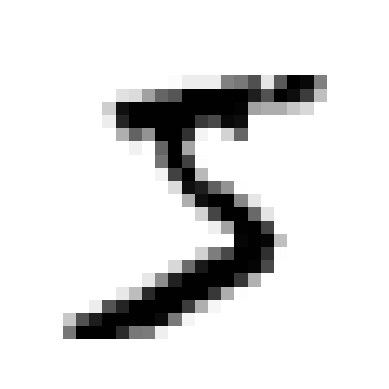

This image contains a 5


In [4]:

X, y = mnist["data"], mnist["target"]
print(f"X has {X.shape[0]} rows and {X.shape[1]} columns")
print(f"y has {y.shape[0]} rows")

# Note that, since X is a DataFrame, we need to select
# the relevant row (i.e. the first image), and then 
# convert it to a numpy array to visualize
first_digit = X.iloc[0].to_numpy()

# We know each image is 28x28 pixels, so
# we need to reshape it to visualize:
first_digit_image = first_digit.reshape(28, 28)

plt.imshow(first_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(f"This image contains a {y[0]}")

Since the y Series contains our labels, which are strictly numerical, we should check the datatype to make sure our classification algorithms, which will use integers, are correct:

In [5]:
type(y[0])

str

Since this is a string, we should convert the entire Series into integer values

In [6]:
y = y.astype(int)
type(y[0])

numpy.int64

### Train/Test Split
Before training any classifiers, we need to make sure that we have split our data into training and testing. We could do this by using train_test_split, but we know that the data is already shuffled, so we can simply select 80% of the data to set aside for training. Note that 80% of the data corresponds to the first 56,000 images.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
24367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033194,-0.023595,-0.017126,-0.010873,-0.00911,-0.005973,0.0,0.0,0.0,0.0
33964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033194,-0.023595,-0.017126,-0.010873,-0.00911,-0.005973,0.0,0.0,0.0,0.0
58668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033194,-0.023595,-0.017126,-0.010873,-0.00911,-0.005973,0.0,0.0,0.0,0.0
63075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033194,-0.023595,-0.017126,-0.010873,-0.00911,-0.005973,0.0,0.0,0.0,0.0
49210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033194,-0.023595,-0.017126,-0.010873,-0.00911,-0.005973,0.0,0.0,0.0,0.0


## 3. Train Models

In [16]:
# Define metrics used for model evaluation
scoring = ['accuracy', 'precision', 'recall', 'f1']

method = []
acc_scores =[]
pre_scores = []
rec_scores = []
f1_scores = []

### 3.1 Stochastic Gradient Descent


In [15]:
sgd_clf = SGDClassifier(random_state=50, max_iter=2500)
sgd_clf.fit(X_train, y_train)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2500
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",50
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [ ]:
cv_results = cross_validate(
    sgd_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())


from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_cv = cross_val_predict(
    tree_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_scorer.py", line 463, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\raymo\AppData\Local\Pyth

### 3.2 Random Forest


In [ ]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

### 3.3 Support Vector Machine

In [ ]:
svm_clf = SVC()
svm_clf.fit(X_train, y_train)

### 3.4 Support Vector Machine (One vs Rest)


In [14]:
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)

KeyboardInterrupt: 

### 3.5 Naive Bayes


In [ ]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)